In [ ]:
!pip install --upgrade sympy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 30.5 MB/s eta 0:00:00
  Attempting uninstall: sympy
    Found existing installation: sympy 1.13.1
    Uninstalling sympy-1.13.1:
      Successfully uninstalled sympy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-nvrtc-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cud

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch
import re
import nltk
from nltk.corpus import stopwords

In [ ]:
# Download stopwords if not already available
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Function for preprocessing the input text
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

In [ ]:
# Function to merge subword tokens into full words
def merge_subwords(tokens):
    words = []
    current_word = ""
    for token in tokens:
        if token.startswith("##"):
            current_word += token[2:]  # Merge subword
        else:
            if current_word:
                words.append(current_word)  # Append previous word
            current_word = token  # Start a new word
    if current_word:
        words.append(current_word)  # Append last word
    return words

In [ ]:
# Step 1: Load the tokenizer
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained("law-ai/InLegalBERT")

Loading tokenizer...


In [ ]:
# Step 2: Get user input text
user_text = input("Enter the legal document text: ")
print("Preprocessing text...")
processed_text = preprocess_text(user_text)
print(f"Processed text: {processed_text}")

Enter the legal document text: The accused was charged under IPC Section 420 for cheating and dishonestly inducing delivery of property. The complainant alleged that the accused fraudulently obtained ₹5,00,000 by promising high returns on investment but failed to deliver.  Further, IPC Section 120B (criminal conspiracy) was invoked, as the investigation revealed that the accused, in collusion with others, devised a scheme to deceive multiple victims. Additionally, the court examined IPC Section 468, which deals with forgery for the purpose of cheating, since fabricated documents were submitted as proof of investment.  During the trial, the prosecution argued that the accused engaged in fraudulent practices and had prior convictions under IPC Section 379 (theft). The defense, however, contended that the transaction was purely civil and did not amount to a criminal offense. The court relied on Supreme Court precedents and relevant SCC citations to assess the liability of the accused.
Pre

In [ ]:
# Step 3: Tokenize the text
print("Tokenizing text...")
tokenized_output = tokenizer(processed_text, return_tensors="pt", truncation=True, max_length=512, return_offsets_mapping=True)
input_ids = tokenized_output["input_ids"]
tokens = tokenizer.convert_ids_to_tokens(input_ids[0])

Tokenizing text...


In [ ]:
# Step 4: Merge subwords back into words
merged_tokens = merge_subwords(tokens)
print(f"Tokenized input (fixed): {merged_tokens}")

Tokenized input (fixed): ['[CLS]', 'the', 'accused', 'was', 'charged', 'under', 'ipc', 'section', '420', 'for', 'cheating', 'and', 'dishonestly', 'inducing', 'delivery', 'of', 'property', 'the', 'complainant', 'alleged', 'that', 'the', 'accused', 'fraudulently', 'obtained', '500000', 'by', 'promising', 'high', 'returns', 'on', 'investment', 'but', 'failed', 'to', 'deliver', 'further', 'ipc', 'section', '120b', 'criminal', 'conspiracy', 'was', 'invoked', 'as', 'the', 'investigation', 'revealed', 'that', 'the', 'accused', 'in', 'collusion', 'with', 'others', 'devised', 'a', 'scheme', 'to', 'deceive', 'multiple', 'victims', 'additionally', 'the', 'court', 'examined', 'ipc', 'section', '468', 'which', 'deals', 'with', 'forgery', 'for', 'the', 'purpose', 'of', 'cheating', 'since', 'fabricated', 'documents', 'were', 'submitted', 'as', 'proof', 'of', 'investment', 'during', 'the', 'trial', 'the', 'prosecution', 'argued', 'that', 'the', 'accused', 'engaged', 'in', 'fraudulent', 'practices', 'a

In [ ]:
# Step 5: Load the model
print("Loading model...")
model = AutoModel.from_pretrained("law-ai/InLegalBERT")

Loading model...


In [ ]:
# Step 6: Generate embeddings
print("Generating embeddings...")
with torch.no_grad():
    # Remove 'offset_mapping' from the input to the model
    output = model(**{k: v for k, v in tokenized_output.items() if k != 'offset_mapping'})

Generating embeddings...


In [ ]:
# Step 7: Extract the last hidden state (embeddings)
last_hidden_state = output.last_hidden_state

In [ ]:
# Step 8: Obtain the sentence embedding (mean pooling)
sentence_embedding = torch.mean(last_hidden_state, dim=1)
print(f"Sentence embedding shape: {sentence_embedding.shape}")
print("Sentence embedding generated successfully.")

Sentence embedding shape: torch.Size([1, 768])
Sentence embedding generated successfully.


In [ ]:
# Step 9: Display word embeddings
print("\nWord-level Embeddings:")
for token, embedding in zip(merged_tokens, last_hidden_state[0]):
    print(f"{token}: {embedding.tolist()}")


Word-level Embeddings:
[CLS]: [-0.41593530774116516, -0.3660399317741394, 0.0424819253385067, -0.42047354578971863, 0.3103812336921692, 0.45341768860816956, 0.00864665862172842, 0.22017663717269897, 0.3565742075443268, -0.3957156240940094, 0.410147488117218, 0.13801376521587372, 0.5448839664459229, -0.141652449965477, 0.28312012553215027, -0.10269720107316971, 0.18710200488567352, -0.3645116686820984, 0.2744154930114746, -0.09659583121538162, -0.21147210896015167, -0.054452307522296906, 0.638608992099762, 0.01891610212624073, 0.2650558054447174, 0.03127792477607727, -0.08080032467842102, -0.1678813397884369, 0.29615068435668945, -0.12758518755435944, 0.47296610474586487, 0.09198380261659622, 0.6737323999404907, 0.1451585739850998, -0.5468164086341858, -0.24250414967536926, 0.11705777049064636, 0.8420015573501587, 0.25501489639282227, 0.31430351734161377, -0.3635671138763428, -0.020414967089891434, -0.34082457423210144, 0.6279637813568115, -0.1856512427330017, 0.19887325167655945, -4.6

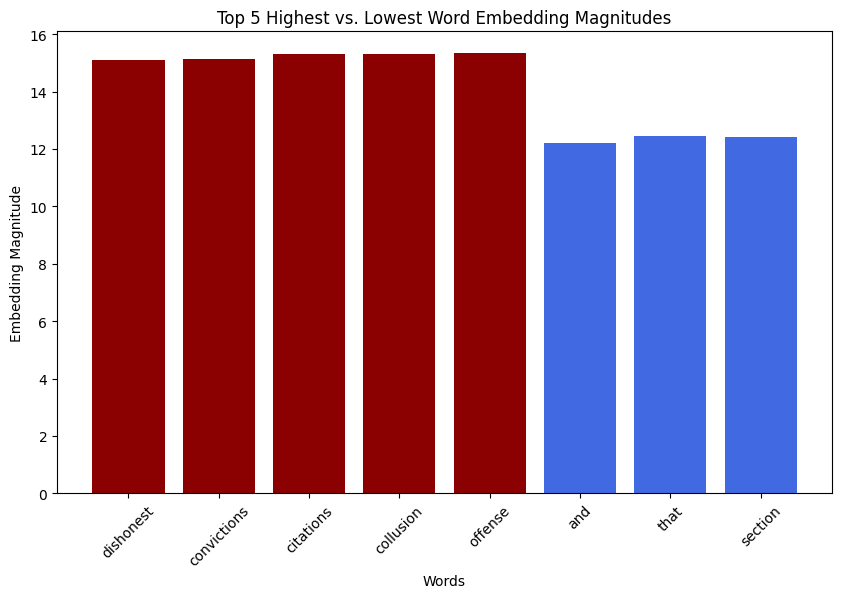


Top 5 Words with Highest Embedding Magnitude:
dishonest: 15.1134
convictions: 15.1207
citations: 15.3002
collusion: 15.3222
offense: 15.3295

Top 5 Words with Lowest Embedding Magnitude:
and: 12.2202
that: 12.3952
section: 12.4100
that: 12.4310
that: 12.4567


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Convert word embeddings to numpy array
word_embeddings = last_hidden_state[0].numpy()

# Compute magnitude of each word's embedding
word_magnitudes = np.linalg.norm(word_embeddings, axis=1)

# Get top 5 words with highest and lowest magnitude
sorted_indices = np.argsort(word_magnitudes)
top_5_lowest = sorted_indices[:5]
top_5_highest = sorted_indices[-5:]

# Extract words and their values
lowest_words = [(tokens[i], word_magnitudes[i]) for i in top_5_lowest]
highest_words = [(tokens[i], word_magnitudes[i]) for i in top_5_highest]

# Combine for plotting
words, values = zip(*(highest_words + lowest_words))
colors = ['darkred'] * 5 + ['royalblue'] * 5  # Different colors for high and low values

# Visualization: Top 5 Highest vs. Lowest Words
plt.figure(figsize=(10, 6))
plt.bar(words, values, color=colors)
plt.xlabel("Words")
plt.ylabel("Embedding Magnitude")
plt.title("Top 5 Highest vs. Lowest Word Embedding Magnitudes")
plt.xticks(rotation=45)
plt.show()

# Print values for reference
print("\nTop 5 Words with Highest Embedding Magnitude:")
for word, value in highest_words:
    print(f"{word}: {value:.4f}")

print("\nTop 5 Words with Lowest Embedding Magnitude:")
for word, value in lowest_words:
    print(f"{word}: {value:.4f}")


In [ ]:
import numpy as np
import networkx as nx
import nltk
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Function to preprocess text
def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Function to remove stopwords
def remove_stopwords(text):
    stop_words = set(stopwords.words("english"))
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

# Function to generate summary using TextRank
def generate_summary(text, num_sentences=3):
    # Step 1: Sentence Tokenization
    sentences = sent_tokenize(text)

    # Step 2: Preprocessing sentences
    processed_sentences = [remove_stopwords(preprocess_text(sentence)) for sentence in sentences]

    # Step 3: Compute sentence embeddings using TF-IDF
    vectorizer = TfidfVectorizer()
    sentence_vectors = vectorizer.fit_transform(processed_sentences).toarray()

    # Step 4: Compute similarity matrix
    similarity_matrix = np.dot(sentence_vectors, sentence_vectors.T)

    # Step 5: Apply PageRank Algorithm
    graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(graph)

    # Step 6: Rank sentences based on scores
    ranked_sentences = sorted(((scores[i], s) for i, s in enumerate(sentences)), reverse=True)

    # Step 7: Select top sentences for the summary
    summary = " ".join([ranked_sentences[i][1] for i in range(min(num_sentences, len(sentences)))])

    return summary

# Get user input text
user_text = input("Enter the legal document text: ")

# Generate summary
summary = generate_summary(user_text, num_sentences=3)

# Display output
print("\nExtractive Summary:\n", summary)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Enter the legal document text: The accused was charged under IPC Section 420 for cheating and dishonestly inducing delivery of property. The complainant alleged that the accused fraudulently obtained ₹5,00,000 by promising high returns on investment but failed to deliver.  Further, IPC Section 120B (criminal conspiracy) was invoked, as the investigation revealed that the accused, in collusion with others, devised a scheme to deceive multiple victims. Additionally, the court examined IPC Section 468, which deals with forgery for the purpose of cheating, since fabricated documents were submitted as proof of investment.  During the trial, the prosecution argued that the accused engaged in fraudulent practices and had prior convictions under IPC Section 379 (theft). The defense, however, contended that the transaction was purely civil and did not amount to a criminal offense. The court relied on Supreme Court precedents and relevant SCC citations to assess the liability of the accused.

Ex

In [ ]:
!pip install rouge_score

  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=d8798fc8ea8afdac174a1a20195458bbc3156f739c9dcedf19b53d41bcbcca06
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


In [ ]:
from rouge_score import rouge_scorer

# Reference summary
reference_summary = """The accused was charged under IPC Section 420 for cheating and dishonestly inducing delivery of property.
Further, IPC Section 120B (criminal conspiracy) was invoked, revealing that the accused, in collusion with others, devised a scheme to deceive multiple victims.
Additionally, the court examined IPC Section 468, which deals with forgery for the purpose of cheating, as fabricated documents were submitted as proof of investment."""

# Extractive summary generated by TextRank or another model
generated_summary = """Additionally, the court examined IPC Section 468, which deals with forgery for the purpose of cheating, since fabricated documents were submitted as proof of investment.
The accused was charged under IPC Section 420 for cheating and dishonestly inducing delivery of property.
Further, IPC Section 120B (criminal conspiracy) was invoked, as the investigation revealed that the accused, in collusion with others, devised a scheme to deceive multiple victims."""

# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

# Compute ROUGE scores
scores = scorer.score(reference_summary, generated_summary)

# Display results
print("ROUGE Scores:")
for key, value in scores.items():
    print(f"{key.upper()}: Precision: {value.precision:.4f}, Recall: {value.recall:.4f}, F1-score: {value.fmeasure:.4f}")


ROUGE Scores:
ROUGE1: Precision: 0.9552, Recall: 1.0000, F1-score: 0.9771
ROUGE2: Precision: 0.8939, Recall: 0.9365, F1-score: 0.9147
ROUGEL: Precision: 0.5821, Recall: 0.6094, F1-score: 0.5954
